# Causal Inference

## Introduction

Causal inference is the method of inferring the causal relationships between variables under study.
It is vital for doing science.

To represent variables and their relationships, we use a mathematical structure called a Directed Acylic Graph (DAG).
This is a kind of graph where variables are nodes and relationships are edges, in which the edges are unidirectional and the graph is without cycles (i.e. there should be no way to start at a node and trace a path through the graph to arrive back at the same node without backtracking).


For example, does smoking cause lung cancer?
Both smoking and lung cancer have a common cause, the age of the person. Cancer is more likely to occur as one ages due to biological factors. Additionally, there is a statistical explanation - if the probability of the event of "getting cancer" is nonzero on a daily basis, then there are simply more chances to get cancer if one lives for more days (akin to how if you play the lottery everyday you are bound to win at some point, although in the case of cancer its really a massive loss).   
Age doesn't cause smoking in a biological sense, but we observe cohort effects where older folks may come from a generation where it was culturally acceptable to smoke. Younger generations (as of the 2020s) do not tend to smoke.

This information can be compactly represented with this DAG:

<center><img src="./img/nb-causal_dag.jpg" width="400" alt="DAG for age, smoking, and lung cancer"/></center>

To recap, we wish to estimate the effect of smoking on cancer, but need to explicitly account for other causes like age.
The rest of the notebook is concerned with how to correctly estimate these causal effects from data.

## Understanding DAGs

A **path** is a subset of connected nodes in a DAG.
We consider the path an **undirected path** if we simply ignore the directionality of the edges of the path.

There are three elementary types of undirected paths in a DAG:

**Mediator**: $X \rightarrow Z \rightarrow Y$

**Confounder**: $X \leftarrow Z \rightarrow Y$

**Collider**: $X \rightarrow Z \leftarrow Y$

Mediators and Confounders are "open" undirected paths, in the sense that information can flow through these paths.
Colliders are "closed" undirected paths, in the sense that information is blocked from flowing through these paths.

This has big implications for how we should decide to include variables in statistical models.
It is _not_ scientifically or even statistically sound to simply throw all the "relevant" variables of your scientific problem into your regression models.
Lets examine the implications of imprudently "controlling" for variables using a linear regression model.

In [1]:
import statistics
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [2]:
plt.style.use("seaborn-v0_8-colorblind")
rng = np.random.default_rng()

In [3]:
def visualize_associations(X, Y, Z):

    scatter = plt.scatter(X, Y, c=Z)
    plt.xlabel("X")
    plt.ylabel("Y")
    cbar = plt.colorbar(scatter)
    cbar.set_label('Z', rotation=270, labelpad=15)
    
    # Modelling without Z
    mdl = LinearRegression().fit(np.array(X).reshape(-1, 1), Y)
    mX = mdl.coef_[0]
    b = float(mdl.intercept_)
    plt.axline(xy1=(0, b), slope=mX, color="red", linewidth=2, label=f"Y = {mX:.2f}X + {b:.2f}")

    
    # Modelling with Z
    mdl_with_Z = LinearRegression().fit(np.array([X, Z]).T, Y)
    mX, mZ = mdl_with_Z.coef_
    b = float(mdl_with_Z.intercept_)
    plt.axline(xy1=(0, b), slope=mZ, color="blue", linewidth=2, label=f"Y = {mX:.2f}X + {mZ:.2f}Z + {b:.2f}")

    plt.legend()
    plt.show()

In [4]:
# Sample parameters
n = 1000

To control for a mediator Z, it makes no difference whether you include it or not


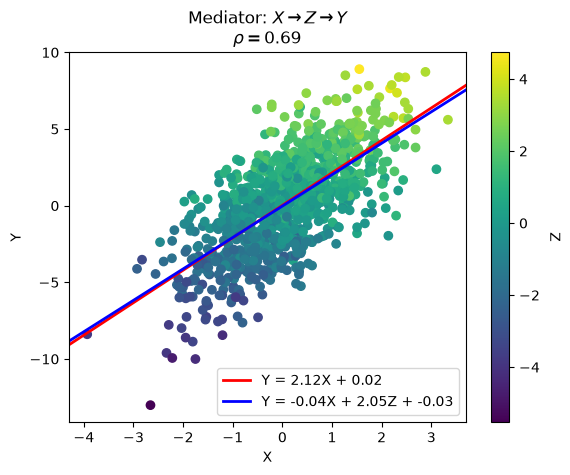

In [5]:
# Mediator - X causes Y, mediated through Z
X = rng.normal(0., 1., n)
Z = rng.normal(X, 1., n)
Y = rng.normal(2*Z, 1., n)

print("To control for a mediator Z, it makes no difference whether you include it or not")
plt.title(f"Mediator: $X \\rightarrow Z \\rightarrow Y$\n$\\rho={statistics.correlation(X, Y):.2f}$")
visualize_associations(X, Y, Z)

To control for a confounder Z, DO include it in your model to avoid bias


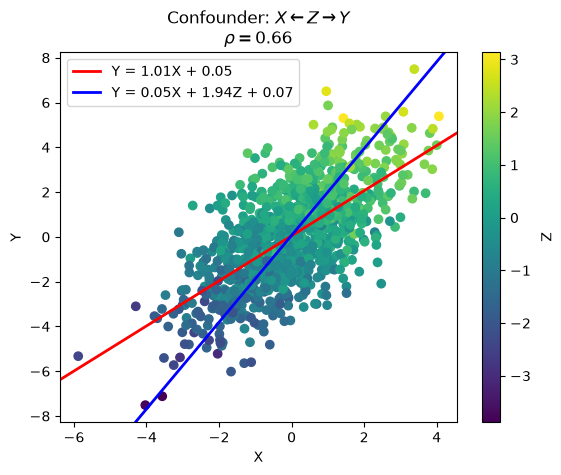

In [6]:
# Confounder - Z is a common cause of X and Y
Z = rng.normal(0., 1., n)
X = rng.normal(Z, 1., n)
Y = rng.normal(2*Z, 1., n)

print("To control for a confounder Z, DO include it in your model to avoid bias")
plt.title(f"Confounder: $X \\leftarrow Z \\rightarrow Y$\n$\\rho={statistics.correlation(X, Y):.2f}$")
visualize_associations(X, Y, Z)

To control for a collider Z, DO NOT include it in your regression model to avoid bias


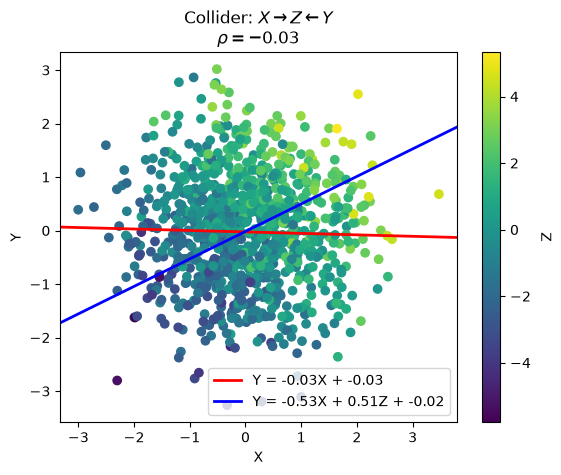

In [7]:
# Collider - X and Y both cause Z, but are independent of each other
X = rng.normal(0., 1., n)
Y = rng.normal(0., 1., n)
Z = rng.normal(X + Y, 1., n)

print("To control for a collider Z, DO NOT include it in your regression model to avoid bias")
plt.title(f"Collider: $X \\rightarrow Z \\leftarrow Y$\n$\\rho={statistics.correlation(X, Y):.2f}$")
visualize_associations(X, Y, Z)